# Live AIS Vessel Tracking via EURIS

This notebook demonstrates how to retrieve live AIS (Automatic Identification System) vessel positions
from the EURIS portal WebSocket API and couple them to the FIS fairway network.

We use **Volkerakssluizen** as a working example — one of the busiest lock complexes in the Netherlands,
connecting the Hollands Diep to the Volkerak.

The API is publicly accessible (no authentication required) at:
`wss://www.eurisportal.eu/api/AISTracks/Connect`

It uses JSON-RPC 2.0 with a `GetFeatures` method that accepts a bounding box filter.

In [ ]:
import asyncio
import json
import pickle
import pathlib

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import websockets
import contextily as cx
from shapely.geometry import box

## 1. Fetch Live AIS Tracks

The EURIS WebSocket API streams AIS position reports as a GeoJSON `FeatureCollection`.
We send a `GetFeatures` request with a bounding box covering the Volkerakssluizen area.

In [2]:
# Volkerakssluizen bounding box
BBOX = {
    "minLat": 51.62,
    "minLon": 4.28,
    "maxLat": 51.70,
    "maxLon": 4.45,
}

AIS_WSS_URL = "wss://www.eurisportal.eu/api/AISTracks/Connect"

In [3]:
async def fetch_ais_tracks(bbox: dict) -> dict:
    """Fetch a snapshot of AIS tracks within the given bounding box."""
    request = {
        "jsonrpc": "2.0",
        "method": "GetFeatures",
        "params": {"filters": {"boundingBox": bbox, "filterQuery": "()"}},
        "id": 1,
    }
    async with websockets.connect(
        AIS_WSS_URL, open_timeout=10, max_size=10 * 1024 * 1024
    ) as ws:
        await ws.send(json.dumps(request))
        response = await asyncio.wait_for(ws.recv(), timeout=15)
    return json.loads(response)["result"]


feature_collection = await fetch_ais_tracks(BBOX)
print(f"Received {len(feature_collection['features'])} AIS tracks")

Received 108 AIS tracks


## 2. Parse into a GeoDataFrame

Each feature contains vessel position (geometry) and properties including:
- **MMSI** — Maritime Mobile Service Identity
- **COG** — Course over ground (degrees)
- **SOG** — Speed over ground (knots)
- **DimA/B** — Distance bow/stern to transponder (metres); vessel length = DimA + DimB
- **DimC/D** — Distance port/starboard to transponder (metres); vessel beam = DimC + DimD
- **TH** — True heading (degrees)
- **ST** — Navigation status

In [4]:
gdf = gpd.GeoDataFrame.from_features(feature_collection["features"], crs="EPSG:4326")

# Derive vessel dimensions
gdf["length_m"] = gdf["DimA"] + gdf["DimB"]
gdf["beam_m"] = gdf["DimC"] + gdf["DimD"]

# Navigation status labels (AIS standard)
STATUS_LABELS = {
    0: "Under way (engine)",
    1: "At anchor",
    2: "Not under command",
    3: "Restricted maneuverability",
    5: "Moored",
    15: "Undefined",
}
gdf["status_label"] = gdf["ST"].map(STATUS_LABELS).fillna("Other")

print(f"Columns: {list(gdf.columns)}")
gdf[["Name", "MMSI", "SOG", "COG", "length_m", "beam_m", "status_label"]].head(10)

Columns: ['geometry', 'Id', 'Lat', 'Lon', 'TrackID', 'MMSI', 'DSP', 'Name', 'JiraTask', 'COG', 'SOG', 'VG', 'VGRT', 'VT', 'Loaded', 'ST', 'LT', 'RT', 'DimA', 'DimB', 'DimC', 'DimD', 'TH', 'HC', 'FollowMode', 'DPK', 'WOID', 'SLC', 'SLID', 'RecTS', 'PosType', 'Followed', 'length_m', 'beam_m', 'status_label']


,Name,MMSI,SOG,COG,length_m,beam_m,status_label
0,Track 848450,0,0.0,0.0,110,12,Not under command
1,Track 838434,0,0.0,0.0,80,10,Not under command
2,Track 835775,0,0.0,0.0,82,9,Not under command
3,Track 836832,0,2.3,51.6,90,12,At anchor
4,Track 854887,0,7.5,61.2,110,23,At anchor
5,Track 838183,0,1.0,236.8,86,11,At anchor
6,Track 825352,0,0.0,0.0,8,3,Not under command
7,Track 856672,0,0.0,0.0,110,12,Not under command
8,Track 849392,0,0.0,0.0,86,10,Not under command
9,Track 826260,0,0.0,141.2,182,12,Not under command


## 3. Explore the Data

Quick summary statistics and vessel status breakdown.

In [5]:
print("=== Vessel Status ===")
print(gdf["status_label"].value_counts().to_string())

print("\n=== Vessel Dimensions (vessels with known dimensions) ===")
known = gdf[gdf["length_m"] > 0]
print(known[["length_m", "beam_m", "SOG"]].describe().round(1).to_string())

=== Vessel Status ===
status_label
Not under command     78
Under way (engine)    16
At anchor             14

=== Vessel Dimensions (vessels with known dimensions) ===
       length_m  beam_m    SOG
count     104.0   104.0  104.0
mean       56.6     8.1    0.8
std        46.0     4.7    2.4
min         4.0     3.0    0.0
25%        15.0     4.0    0.0
50%        35.0     6.0    0.0
75%       100.5    11.2    0.0
max       182.0    24.0   10.1


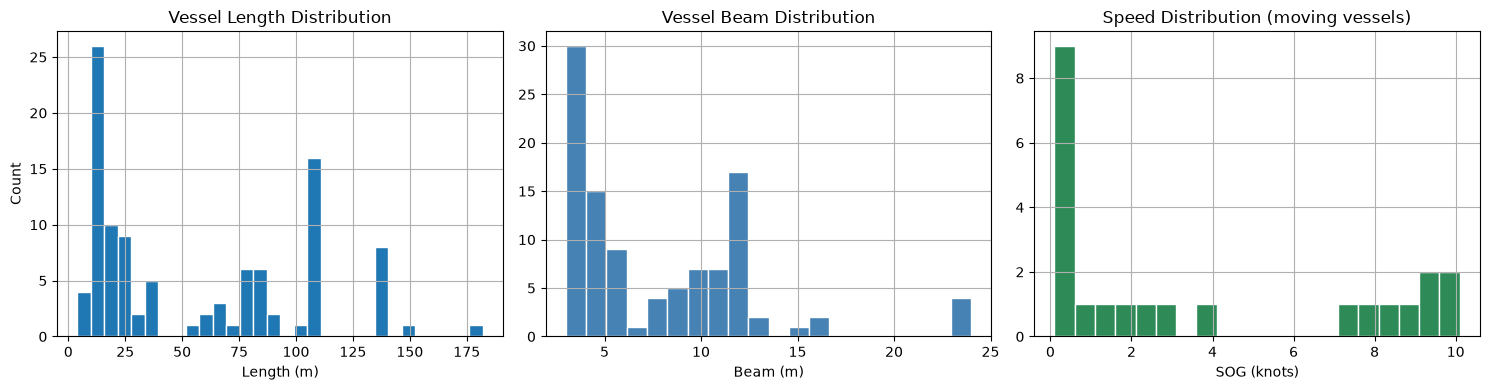

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

known["length_m"].hist(bins=30, ax=axes[0], edgecolor="white")
axes[0].set_title("Vessel Length Distribution")
axes[0].set_xlabel("Length (m)")
axes[0].set_ylabel("Count")

known["beam_m"].hist(bins=20, ax=axes[1], edgecolor="white", color="steelblue")
axes[1].set_title("Vessel Beam Distribution")
axes[1].set_xlabel("Beam (m)")

known[known["SOG"] > 0]["SOG"].hist(
    bins=20, ax=axes[2], edgecolor="white", color="seagreen"
)
axes[2].set_title("Speed Distribution (moving vessels)")
axes[2].set_xlabel("SOG (knots)")

plt.tight_layout()
plt.show()

## 4. Map: Live Vessel Positions at Volkerakssluizen

Vessels are coloured by navigation status. Size reflects vessel length.

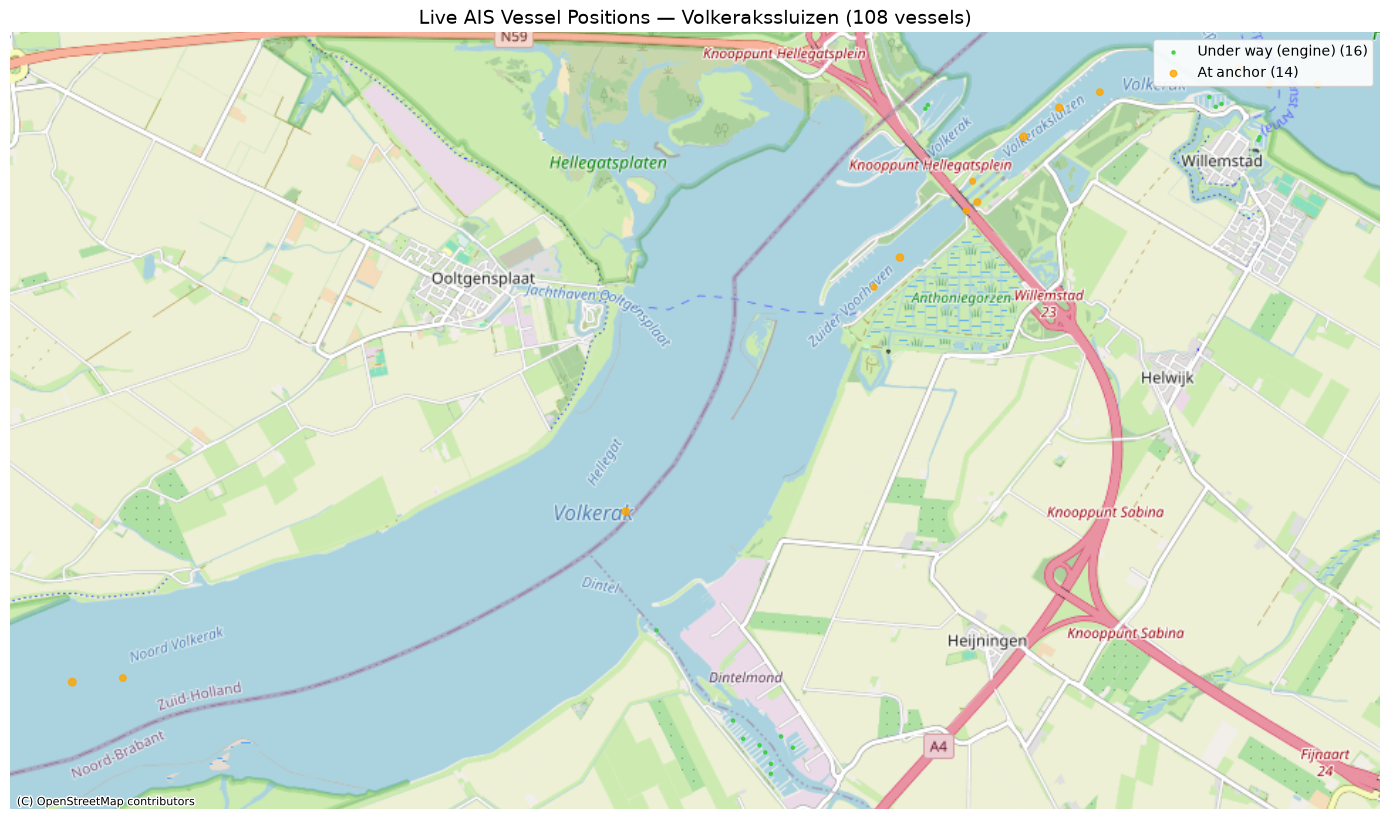

In [7]:
gdf_web = gdf.to_crs(epsg=3857)

STATUS_COLORS = {
    "Under way (engine)": "limegreen",
    "At anchor": "orange",
    "Moored": "steelblue",
    "Restricted maneuverability": "red",
    "Other": "gray",
    "Undefined": "lightgray",
}

fig, ax = plt.subplots(figsize=(14, 10))

for status, color in STATUS_COLORS.items():
    subset = gdf_web[gdf_web["status_label"] == status]
    if subset.empty:
        continue
    sizes = np.clip(subset["length_m"] / 5, 5, 80)
    subset.plot(
        ax=ax,
        color=color,
        markersize=sizes,
        alpha=0.8,
        label=f"{status} ({len(subset)})",
    )

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_title(
    f"Live AIS Vessel Positions — Volkerakssluizen ({len(gdf)} vessels)",
    fontsize=14,
)
ax.legend(loc="upper right", framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Snap Vessels to the Fairway Network

We load the merged FIS/EURIS graph and find the nearest network node for each vessel.
This enables downstream analysis such as determining which fairway section a vessel is on.

In [ ]:
from scipy.spatial import cKDTree

graph_path = pathlib.Path("../output/merged-graph/graph.pickle")
with graph_path.open("rb") as f:
    graph = pickle.load(f)

nodes_gdf = gpd.GeoDataFrame(
    graph.nodes.values(), index=graph.nodes.keys(), geometry="geometry", crs="EPSG:4326"
)

# Restrict to nodes within the bounding box for efficiency
bbox_geom = box(BBOX["minLon"], BBOX["minLat"], BBOX["maxLon"], BBOX["maxLat"])
local_nodes = nodes_gdf[nodes_gdf.geometry.within(bbox_geom)]
print(f"Network nodes in area: {len(local_nodes)}")

node_coords = np.array(list(zip(local_nodes.geometry.x, local_nodes.geometry.y)))
tree = cKDTree(node_coords)

vessel_coords = np.array(list(zip(gdf.geometry.x, gdf.geometry.y)))
distances, indices = tree.query(vessel_coords)

gdf["nearest_node"] = local_nodes.index[indices].values
gdf["snap_distance_m"] = distances * 111_320  # approx degrees → metres

print("\nSnap distance stats (m):")
print(gdf["snap_distance_m"].describe().round(1).to_string())

In [9]:
# Vessels within 200 m of a network node are considered "on" the network
ON_NETWORK_THRESHOLD_M = 200
on_network = gdf[gdf["snap_distance_m"] <= ON_NETWORK_THRESHOLD_M]

print(
    f"Vessels on network (≤{ON_NETWORK_THRESHOLD_M} m): "
    f"{len(on_network)} / {len(gdf)} ({100 * len(on_network) / len(gdf):.0f}%)"
)

# Which network nodes have the most vessels?
node_counts = on_network.groupby("nearest_node").size().sort_values(ascending=False)
print("\nTop 5 busiest network nodes:")
print(node_counts.head().to_string())

Vessels on network (≤200 m): 45 / 108 (42%)

Top 5 busiest network nodes:
nearest_node
FIS_8862741          11
FIS_harbour_26478     9
FIS_harbour_6777      6
FIS_8863640           4
FIS_8865006           4


## 6. Streaming: Subscribe to Position Updates

The EURIS WebSocket also pushes live updates. After the initial `GetFeatures` snapshot,
the connection remains open and the server sends delta updates as vessels move.
The cell below collects updates for 30 seconds and prints any new messages received.

In [10]:
async def stream_ais_updates(bbox: dict, duration_s: int = 30):
    """Collect streaming AIS updates for `duration_s` seconds."""
    request = {
        "jsonrpc": "2.0",
        "method": "GetFeatures",
        "params": {"filters": {"boundingBox": bbox, "filterQuery": "()"}},
        "id": 1,
    }
    updates = []
    async with websockets.connect(
        AIS_WSS_URL, open_timeout=10, max_size=10 * 1024 * 1024
    ) as ws:
        await ws.send(json.dumps(request))
        snapshot = json.loads(await asyncio.wait_for(ws.recv(), timeout=15))
        print(f"Snapshot: {len(snapshot['result']['features'])} vessels")
        deadline = asyncio.get_event_loop().time() + duration_s
        while asyncio.get_event_loop().time() < deadline:
            try:
                msg = await asyncio.wait_for(ws.recv(), timeout=5)
                updates.append(json.loads(msg))
                print(f"  Update received: {msg[:120]}")
            except asyncio.TimeoutError:
                pass
    return updates


# Uncomment to run live streaming:
# updates = await stream_ais_updates(BBOX, duration_s=30)